In [44]:
import numpy as np
import pandas
import pandas as pd
from pathlib import Path
import cv2
from matplotlib import pyplot as plt

In [45]:
path_ccw = "../data/raw/CCW/driving_log.csv"
path_cw = "../data/raw/CW/driving_log.csv"

In [46]:
columns = ["center", "left", "right", "steering", "throttle", "brake", "speed"]
df_ccw = pd.read_csv(path_ccw, header=None, names=columns)
df_cw = pd.read_csv(path_cw, header=None, names=columns)

In [47]:
df_ccw = df_ccw[["center", "steering", "throttle", "brake", "speed"]]
df_cw = df_cw[["center", "steering", "throttle", "brake", "speed"]]
results_df = pd.concat([df_ccw, df_cw], ignore_index=True)


In [48]:
steering_values_max = max(max(df_cw["steering"]), max(df_ccw["steering"]))
steering_values_min = min(min(df_cw["steering"]), min(df_ccw["steering"]))
print(f"Steering Values Range: [{steering_values_min}, {steering_values_max}]")

Steering Values Range: [-0.5413534, 0.3120301]


In [167]:
bins = np.arange(-0.5, 0.35, 0.05)
print(bins)

[-5.00000000e-01 -4.50000000e-01 -4.00000000e-01 -3.50000000e-01
 -3.00000000e-01 -2.50000000e-01 -2.00000000e-01 -1.50000000e-01
 -1.00000000e-01 -5.00000000e-02 -1.11022302e-16  5.00000000e-02
  1.00000000e-01  1.50000000e-01  2.00000000e-01  2.50000000e-01
  3.00000000e-01]


In [168]:
steering_values = results_df["steering"].values
steering_values_binned = np.digitize(steering_values, bins)
print(steering_values_binned)

[11 11 11 ... 11 11 11]


In [169]:
results_df["steering_bin"] = steering_values_binned
results_df[400:410]

,center,steering,throttle,brake,speed,steering_bin
400,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,-0.018797,1.0,0,30.19033,10
401,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,-0.018797,1.0,0,30.19028,10
402,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,-0.018797,1.0,0,30.19031,10
403,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,-0.018797,1.0,0,30.19029,10
404,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,-0.011278,1.0,0,30.19029,10
405,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,-0.003759,1.0,0,30.19028,10
406,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,0.000000,1.0,0,30.19028,11
407,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,0.000000,1.0,0,30.19030,11
408,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,0.000000,1.0,0,30.19027,11
409,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,0.000000,1.0,0,30.19029,11


In [175]:
def bin_count(df, column, _bins):
    return {i: len(df[df[column] == i]) for i in range(0, len(_bins) + 1)}

In [176]:
print(f"Bin Counts Before Balance: {bin_count(results_df, 'steering_bin', bins)}")

Bin Counts Before Balance: {0: 2, 1: 0, 2: 5, 3: 0, 4: 8, 5: 81, 6: 206, 7: 380, 8: 490, 9: 1251, 10: 3357, 11: 5208, 12: 1461, 13: 510, 14: 327, 15: 254, 16: 61, 17: 12}


In [177]:
bin_counter = {i:0 for i in range(len(bins) + 1)}
idx_to_add = []

for row in results_df.sample(frac=1).itertuples(index=True, name='Pandas'):
        if bin_counter[row.steering_bin] < 200:
            idx_to_add.append(row.Index)
            bin_counter[row.steering_bin] += 1

balanced_df = results_df.loc[idx_to_add]


In [178]:
print(f"Bin Counts After Balance: {bin_count(balanced_df, 'steering_bin', bins)}")

Bin Counts After Balance: {0: 2, 1: 0, 2: 5, 3: 0, 4: 8, 5: 81, 6: 200, 7: 200, 8: 200, 9: 200, 10: 200, 11: 200, 12: 200, 13: 200, 14: 200, 15: 200, 16: 61, 17: 12}


In [179]:
balanced_df.head()

,center,steering,throttle,brake,speed,steering_bin
12118,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,0.030075,1.0,0,30.19024,11
2327,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,0.075188,1.0,0,30.18970,12
3724,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,-0.180451,1.0,0,30.18961,7
285,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,-0.045113,1.0,0,30.19026,10
3197,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,-0.022556,1.0,0,30.19015,10


Text(0, 0.5, 'Frequency')

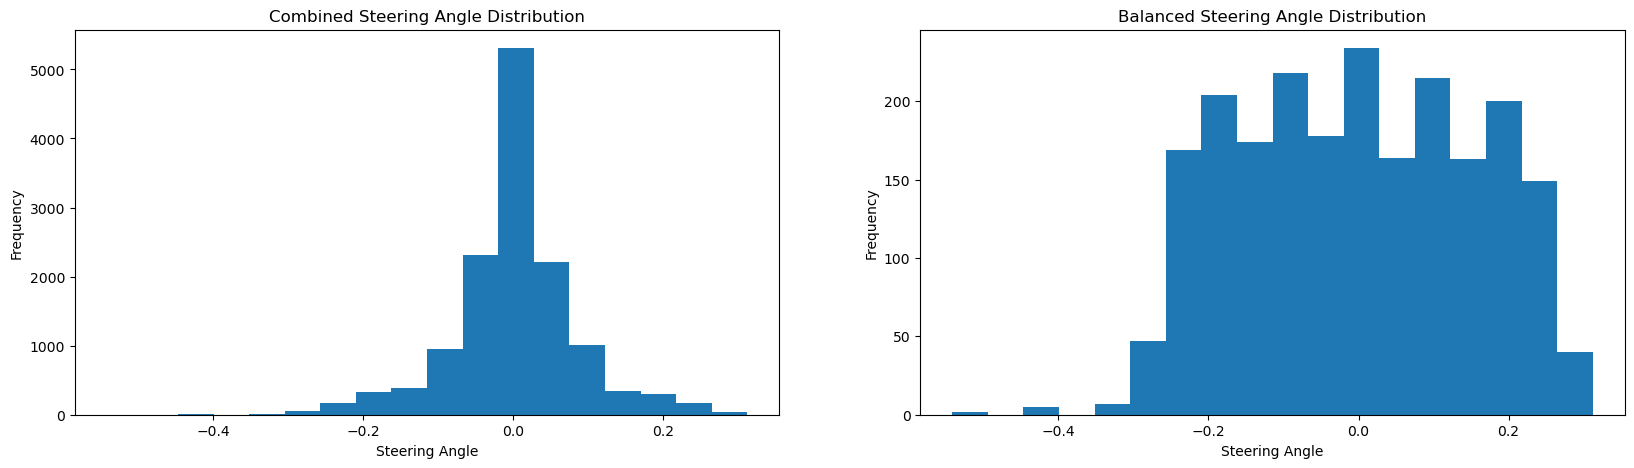

In [180]:
fig,axs = plt.subplots(1,2, figsize=(20,5))
axs[0].hist(results_df["steering"], bins=18)
axs[0].set_title("Combined Steering Angle Distribution")
axs[0].set_xlabel("Steering Angle")
axs[0].set_ylabel("Frequency")
axs[1].hist(balanced_df["steering"], bins=18)
axs[1].set_title("Balanced Steering Angle Distribution")
axs[1].set_xlabel("Steering Angle")
axs[1].set_ylabel("Frequency")